In [43]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [44]:
df = pd.read_csv("Food_Delivery_Times.csv")

In [45]:
df.head()

,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [46]:
df.shape

(1000, 9)

In [47]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Order_ID                1000 non-null   int64  
 1   Distance_km             1000 non-null   float64
 2   Weather                 970 non-null    object 
 3   Traffic_Level           970 non-null    object 
 4   Time_of_Day             970 non-null    object 
 5   Vehicle_Type            1000 non-null   object 
 6   Preparation_Time_min    1000 non-null   int64  
 7   Courier_Experience_yrs  970 non-null    float64
 8   Delivery_Time_min       1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [48]:
# Calculate the mode for categorical columns and mean for numerical column
weather_mode = df['Weather'].mode()[0]
traffic_mode = df['Traffic_Level'].mode()[0]
time_of_day_mode = df['Time_of_Day'].mode()[0]
courier_experience_mean = df['Courier_Experience_yrs'].mean()

# Fill null values
df['Weather'].fillna(weather_mode, inplace=True)
df['Traffic_Level'].fillna(traffic_mode, inplace=True)
df['Time_of_Day'].fillna(time_of_day_mode, inplace=True)
df['Courier_Experience_yrs'].fillna(courier_experience_mean, inplace=True)

print("Null values after filling:")
display(df.isnull().sum())

Null values after filling:


,0
Order_ID,0
Distance_km,0
Weather,0
Traffic_Level,0
Time_of_Day,0
Vehicle_Type,0
Preparation_Time_min,0
Courier_Experience_yrs,0
Delivery_Time_min,0


In [49]:
df.drop('Order_ID', axis=1, inplace=True)
display(df.head())

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,19.03,Clear,Low,Morning,Bike,16,5.0,68


### Exploratory Data Analysis (EDA) on `Delivery_Time_min`

Let's start by understanding the distribution of our target variable: `Delivery_Time_min`.

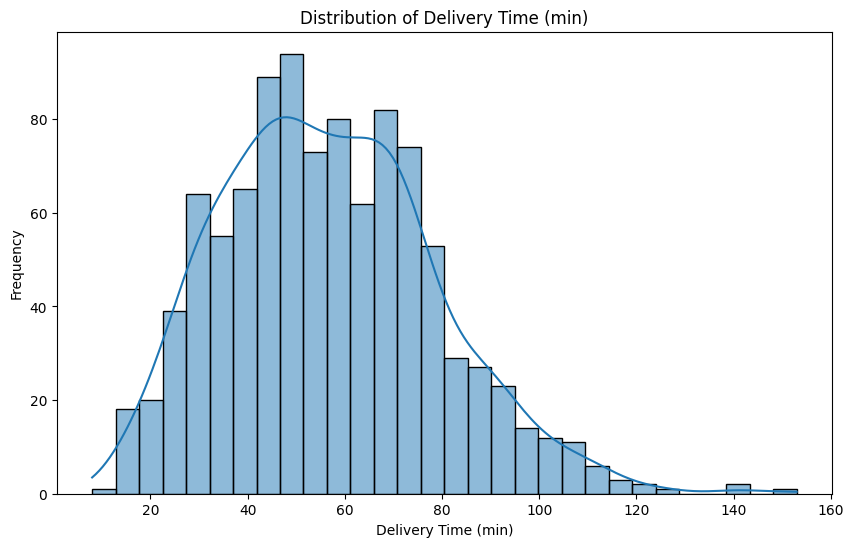

In [50]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Delivery_Time_min'], kde=True, bins=30)
plt.title('Distribution of Delivery Time (min)')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')
plt.show()

Next, let's look at the descriptive statistics for `Delivery_Time_min` to get a quantitative summary.

In [51]:
print("Descriptive statistics for Delivery_Time_min:")
display(df['Delivery_Time_min'].describe())

Descriptive statistics for Delivery_Time_min:


,Delivery_Time_min
count,1000.000000
mean,56.732000
std,22.070915
min,8.000000
25%,41.000000
50%,55.500000
75%,71.000000
max,153.000000


Now, let's investigate the correlation between `Delivery_Time_min` and other numerical features.

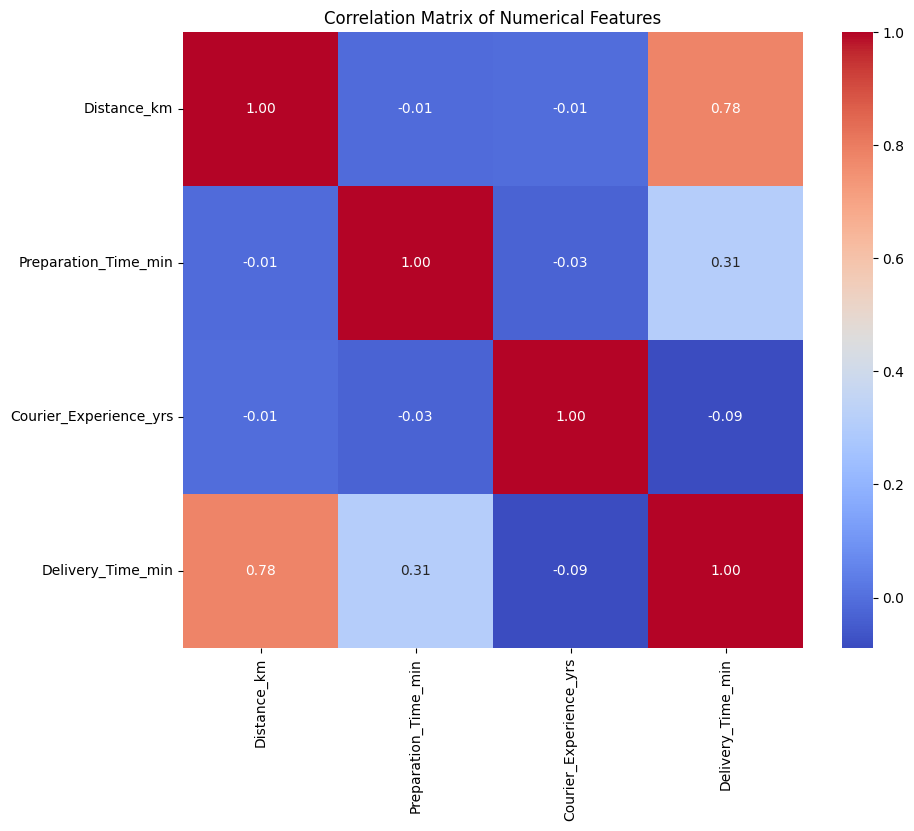

In [52]:
numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns
correlation_matrix = df[numerical_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numerical Features')
plt.show()

### Relationship between Categorical Features and `Delivery_Time_min`

Let's analyze how categorical features influence the delivery time. We'll use box plots to visualize the distribution of `Delivery_Time_min` across different categories and also calculate the mean delivery time for each category.

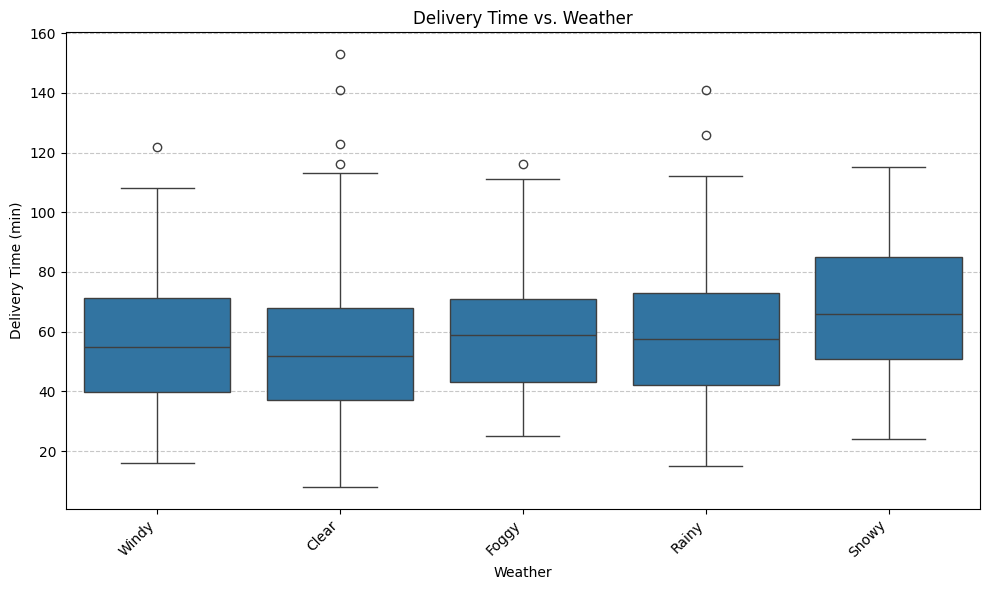


Mean Delivery Time by Weather:


,Delivery_Time_min
Weather,
Snowy,67.113402
Rainy,59.794118
Foggy,59.466019
Windy,55.458333
Clear,53.150000


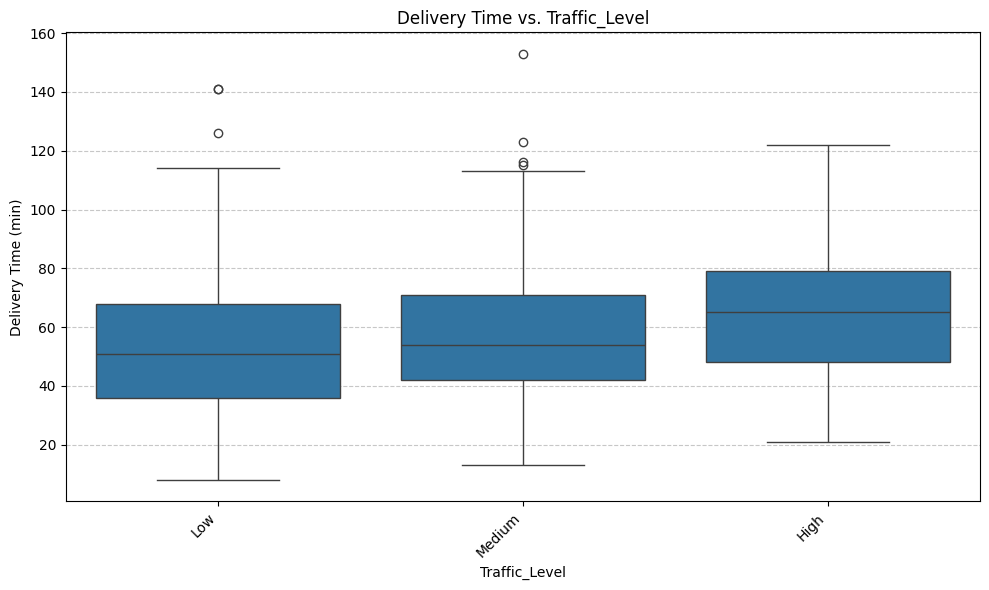


Mean Delivery Time by Traffic_Level:


,Delivery_Time_min
Traffic_Level,
High,64.807107
Medium,56.452381
Low,52.885117


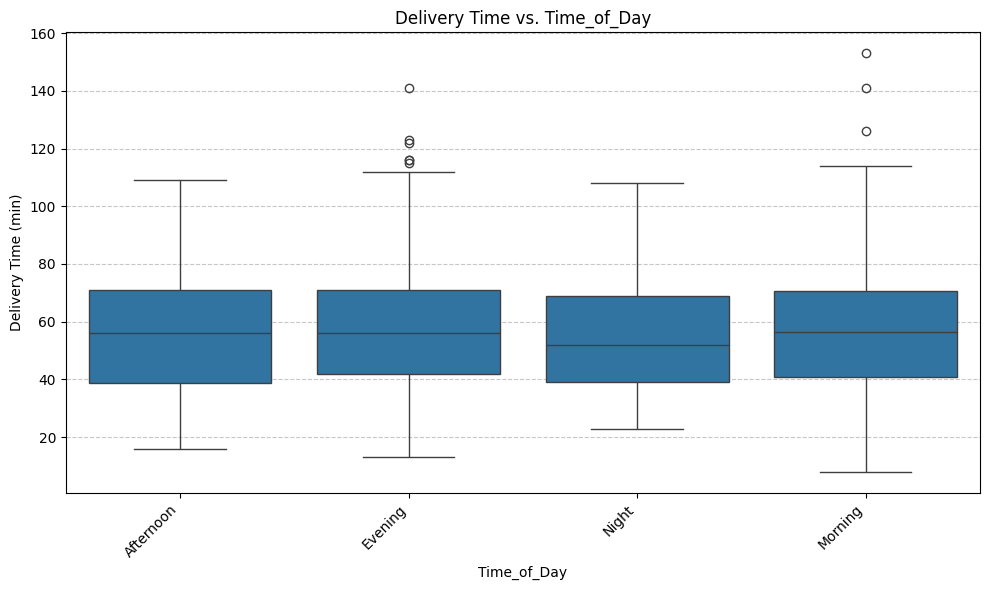


Mean Delivery Time by Time_of_Day:


,Delivery_Time_min
Time_of_Day,
Evening,57.481229
Morning,57.011834
Afternoon,56.080986
Night,55.211765


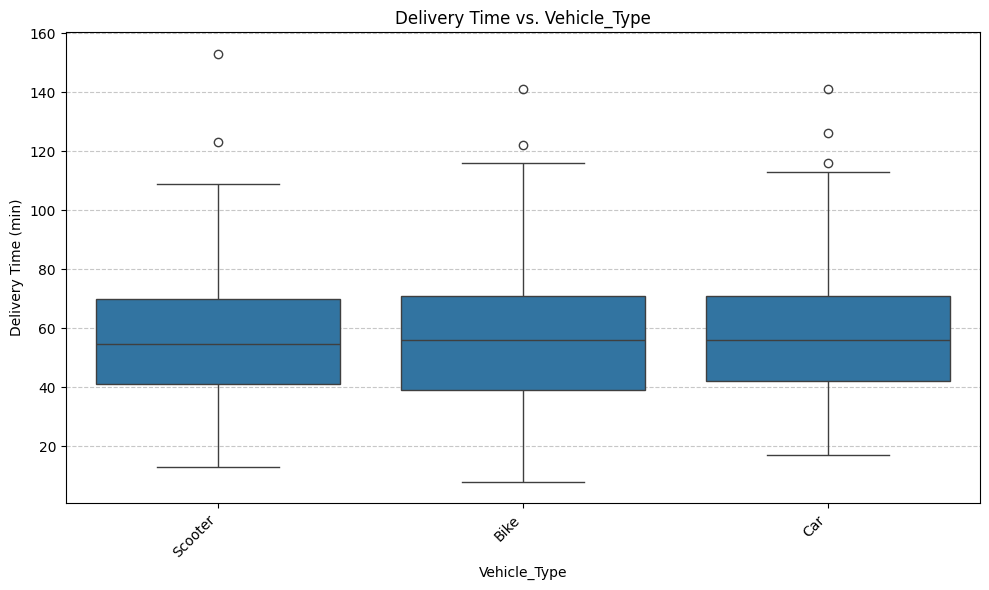


Mean Delivery Time by Vehicle_Type:


,Delivery_Time_min
Vehicle_Type,
Car,58.200000
Bike,56.574553
Scooter,56.046358


In [53]:
categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=col, y='Delivery_Time_min', data=df)
    plt.title(f'Delivery Time vs. {col}')
    plt.xlabel(col)
    plt.ylabel('Delivery Time (min)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

    print(f"\nMean Delivery Time by {col}:")
    display(df.groupby(col)['Delivery_Time_min'].mean().sort_values(ascending=False))

In [54]:
from sklearn.preprocessing import LabelEncoder

cat_col = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']
for col in cat_col:
    label_encoder = LabelEncoder()
    df[col] = label_encoder.fit_transform(df[col])

df.head()

,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,7.93,4,1,0,2,12,1.0,43
1,16.42,0,2,1,0,20,2.0,84
2,9.52,1,1,3,2,28,1.0,59
3,7.44,2,2,0,2,5,1.0,37
4,19.03,0,1,2,0,16,5.0,68


### Statistical Testing for Feature Selection

To identify the best features, we'll perform statistical tests. For categorical features, we can use ANOVA (Analysis of Variance) to check if the mean `Delivery_Time_min` varies significantly across different categories. For numerical features, we've already visualized their correlation with `Delivery_Time_min`.

In [55]:
from scipy.stats import f_oneway

print("\n--- ANOVA Test for Categorical Features ---")

categorical_cols = ['Weather', 'Traffic_Level', 'Time_of_Day', 'Vehicle_Type']

for col in categorical_cols:
    groups = []
    for category in df[col].unique():
        groups.append(df[df[col] == category]['Delivery_Time_min'])

    f_statistic, p_value = f_oneway(*groups)

    print(f"\nANOVA for '{col}':")
    print(f"F-statistic: {f_statistic:.2f}")
    print(f"P-value: {p_value:.3f}")

    if p_value < 0.05:
        print(f"Conclusion: '{col}' is statistically significant (p < 0.05), suggesting it has a significant impact on Delivery_Time_min.")
    else:
        print(f"Conclusion: '{col}' is not statistically significant (p >= 0.05), suggesting it does not have a significant impact on Delivery_Time_min.")


--- ANOVA Test for Categorical Features ---

ANOVA for 'Weather':
F-statistic: 10.50
P-value: 0.000
Conclusion: 'Weather' is statistically significant (p < 0.05), suggesting it has a significant impact on Delivery_Time_min.

ANOVA for 'Traffic_Level':
F-statistic: 19.75
P-value: 0.000
Conclusion: 'Traffic_Level' is statistically significant (p < 0.05), suggesting it has a significant impact on Delivery_Time_min.

ANOVA for 'Time_of_Day':
F-statistic: 0.35
P-value: 0.792
Conclusion: 'Time_of_Day' is not statistically significant (p >= 0.05), suggesting it does not have a significant impact on Delivery_Time_min.

ANOVA for 'Vehicle_Type':
F-statistic: 0.59
P-value: 0.555
Conclusion: 'Vehicle_Type' is not statistically significant (p >= 0.05), suggesting it does not have a significant impact on Delivery_Time_min.


### Summary of Feature Importance

Based on the correlation matrix (for numerical features) and ANOVA tests (for categorical features):

*   **Numerical Features:**
    *   `Distance_km` has a strong positive correlation (0.78) with `Delivery_Time_min`.
    *   `Preparation_Time_min` has a moderate positive correlation (0.31) with `Delivery_Time_min`.
    *   `Courier_Experience_yrs` has a weak negative correlation (-0.09) with `Delivery_Time_min`.

*   **Categorical Features (from ANOVA):**
    *   We can conclude which categorical features are statistically significant in influencing `Delivery_Time_min` based on the p-values from the ANOVA tests above.

### Features Impacting Delivery Time (`Delivery_Time_min`)

| Feature Name           | Type        | Impact on `Delivery_Time_min` |
|:-----------------------|:------------|:------------------------------|
| `Distance_km`          | Numerical   | Strong positive correlation   |
| `Preparation_Time_min` | Numerical   | Moderate positive correlation |
| `Weather`              | Categorical | Statistically significant     |
| `Traffic_Level`        | Categorical | Statistically significant     |

In [56]:
significant_features = ['Distance_km', 'Preparation_Time_min', 'Weather', 'Traffic_Level']
print(significant_features)

['Distance_km', 'Preparation_Time_min', 'Weather', 'Traffic_Level']


In [57]:
# X = df.drop('Delivery_Time_min', axis=1)
X = df[['Distance_km', 'Preparation_Time_min', 'Weather', 'Traffic_Level']]
y = df['Delivery_Time_min']

In [58]:
X.shape

(1000, 4)

In [59]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Decision Tree Regressor Model

Let's train a Decision Tree Regressor model with default parameters to predict `Delivery_Time_min`.

In [60]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# Initialize the Decision Tree Regressor with default parameters
dtree_model = DecisionTreeRegressor(random_state=42)

# Train the model
dtree_model.fit(X_train, y_train)

DecisionTreeRegressor(random_state=42)

In [61]:
y_pred = dtree_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R-squared (R2) Score: {r2:.2f}")

Mean Absolute Error (MAE): 10.51
R-squared (R2) Score: 0.48


### Random Forest Regressor Model

Now, let's build a Random Forest Regressor model. We'll start with a relatively simple configuration by setting `n_estimators` to 50 (number of trees in the forest) to demonstrate a non-default parameter, and then evaluate its performance.

In [62]:
from sklearn.ensemble import RandomForestRegressor

# Initialize the Random Forest Regressor with a non-default parameter (e.g., n_estimators)
# Setting n_estimators to 50 for a 'simple' model as requested, and random_state for reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

### Evaluate Random Forest Regressor Performance

Let's evaluate the Random Forest model using the Mean Absolute Error (MAE) and R-squared score.

In [63]:
# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mae_rf = mean_absolute_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - Mean Absolute Error (MAE): {mae_rf:.2f}")
print(f"Random Forest - R-squared (R2) Score: {r2_rf:.2f}")

Random Forest - Mean Absolute Error (MAE): 7.39
Random Forest - R-squared (R2) Score: 0.76


### Hyperparameter Tuning for Random Forest Regressor

Now, let's perform hyperparameter tuning using `GridSearchCV` to find the best parameters for our Random Forest model. We will tune `n_estimators`, `max_features`, and `max_depth` to optimize the R-squared score.

In [64]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid to search
param_grid = {
    'n_estimators': [50, 100, 200],  # Number of trees in the forest
    'max_features': ['sqrt', 'log2', None], # Number of features to consider when looking for the best split
    'max_depth': [10, 20, 30, None]  # Maximum depth of the tree
}

# Initialize a new RandomForestRegressor model
rf = RandomForestRegressor(random_state=42)

# Initialize GridSearchCV
# We'll use r2 as the scoring metric, and 3-fold cross-validation
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid,
                           cv=3, n_jobs=-1, verbose=2, scoring='r2')

# Fit GridSearchCV to the training data
grid_search.fit(X_train, y_train)

# Print the best parameters and best score
print("\nBest parameters found: ", grid_search.best_params_)
print("Best R-squared score found: {:.2f}".format(grid_search.best_score_))

Fitting 3 folds for each of 36 candidates, totalling 108 fits

Best parameters found:  {'max_depth': 10, 'max_features': 'sqrt', 'n_estimators': 200}
Best R-squared score found: 0.71


### Evaluate Tuned Random Forest Regressor Performance

Let's evaluate the performance of the Random Forest model with the best hyperparameters found by `GridSearchCV`.

In [65]:
# Get the best model from GridSearchCV
best_rf_model = grid_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned_rf = best_rf_model.predict(X_test)

# Evaluate the tuned model
mae_tuned_rf = mean_absolute_error(y_test, y_pred_tuned_rf)
r2_tuned_rf = r2_score(y_test, y_pred_tuned_rf)

print(f"Tuned Random Forest - Mean Absolute Error (MAE): {mae_tuned_rf:.2f}")
print(f"Tuned Random Forest - R-squared (R2) Score: {r2_tuned_rf:.2f}")

Tuned Random Forest - Mean Absolute Error (MAE): 7.16
Tuned Random Forest - R-squared (R2) Score: 0.77


### Hyperparameter Tuning for Random Forest Regressor using RandomizedSearchCV

Now, let's explore `RandomizedSearchCV` for hyperparameter tuning. This approach is often more computationally efficient than `GridSearchCV` when the search space is large, as it randomly samples a fixed number of parameter combinations from the specified distributions. We will tune `n_estimators`, `max_features`, and `max_depth` to optimize the R-squared score.

In [66]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

# Define the parameter distributions to sample from
param_distributions = {
    'n_estimators': randint(50, 201),  # Number of trees in the forest (integer between 50 and 200)
    'max_features': ['sqrt', 'log2', None], # Number of features to consider when looking for the best split
    'max_depth': randint(5, 41) # Maximum depth of the tree (integer between 5 and 40)
}

# Initialize a new RandomForestRegressor model
rf = RandomForestRegressor(random_state=42)

# Initialize RandomizedSearchCV
# We'll sample 50 different combinations (n_iter=50) and use r2 as the scoring metric with 3-fold cross-validation
random_search = RandomizedSearchCV(estimator=rf, param_distributions=param_distributions,
                                   n_iter=50, cv=3, n_jobs=-1, verbose=2, scoring='r2', random_state=42)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

# Print the best parameters and best score
print("\nBest parameters found by RandomizedSearchCV: ", random_search.best_params_)
print("Best R-squared score found by RandomizedSearchCV: {:.2f}".format(random_search.best_score_))

Fitting 3 folds for each of 50 candidates, totalling 150 fits

Best parameters found by RandomizedSearchCV:  {'max_depth': 9, 'max_features': 'log2', 'n_estimators': 191}
Best R-squared score found by RandomizedSearchCV: 0.72


### Evaluate Tuned Random Forest Regressor Performance (RandomizedSearchCV)

Let's evaluate the performance of the Random Forest model with the best hyperparameters found by `RandomizedSearchCV`.

In [67]:
# Get the best model from RandomizedSearchCV
best_rf_model_rand = random_search.best_estimator_

# Make predictions on the test set with the best model
y_pred_tuned_rf_rand = best_rf_model_rand.predict(X_test)

# Evaluate the tuned model
mae_tuned_rf_rand = mean_absolute_error(y_test, y_pred_tuned_rf_rand)
r2_tuned_rf_rand = r2_score(y_test, y_pred_tuned_rf_rand)

print(f"Tuned Random Forest (RandomizedSearchCV) - Mean Absolute Error (MAE): {mae_tuned_rf_rand:.2f}")
print(f"Tuned Random Forest (RandomizedSearchCV) - R-squared (R2) Score: {r2_tuned_rf_rand:.2f}")

Tuned Random Forest (RandomizedSearchCV) - Mean Absolute Error (MAE): 7.19
Tuned Random Forest (RandomizedSearchCV) - R-squared (R2) Score: 0.77


In [68]:
import joblib
import os

# Create the deployment artifacts directory if it doesn't exist
if not os.path.exists(output_dir):
    os.makedirs(output_dir)


In [69]:
# Save the best Random Forest model
joblib.dump(best_rf_model_rand, os.path.join(output_dir, 'best_random_forest_model.pkl'))
print(f"Best Random Forest model saved to {output_dir}/best_random_forest_model.pkl")


Best Random Forest model saved to deployment_artifacts/best_random_forest_model.pkl


In [70]:
# Save the list of significant features
joblib.dump(significant_features, os.path.join(output_dir, 'model_features.pkl'))
print(f"Significant features list saved to {output_dir}/model_features.pkl")

Significant features list saved to deployment_artifacts/model_features.pkl
